# Week 2 Assignment - ML Pipeline on Tesla Sales/Delivery Data
**Name:** Ghanist Agrawal  
**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
**Task:** Build an end-to-end ML pipeline covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning and time series forecasting

In [2]:
# importing everything i need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
import joblib

## Loading the dataset

In [4]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df.shape

(2640, 12)

In [6]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [8]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Data Cleaning
removing duplicates, handling missing values and fixing data types

In [10]:
# check missing values first
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [11]:
# removing duplicates
df.drop_duplicates(inplace=True)
print('shape after removing duplicates:', df.shape)

shape after removing duplicates: (2640, 12)


In [12]:
# filling missing numeric values with median (median is better than mean when there are outliers)
for col in ['Avg_Price_USD', 'Range_km', 'Production_Units']:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# cant do anything if the target column itself is missing so just drop those rows
df.dropna(subset=['Estimated_Deliveries'], inplace=True)

# drop any column that has string notes/metadata - not useful for modeling
note_cols = [c for c in df.columns
             if df[c].dtype == 'object' and c not in ['Region', 'Model']]
if note_cols:
    print('dropping these non-useful text columns:', note_cols)
    df.drop(columns=note_cols, inplace=True)

print('missing values after cleaning:')
print(df.isnull().sum())

dropping these non-useful text columns: ['Source_Type']
missing values after cleaning:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Charging_Stations       0
dtype: int64


In [13]:
df.dtypes

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Charging_Stations         int64
dtype: object

In [14]:
# creating a proper date column from year and month - useful for time series later
df['date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))
df = df.sort_values('date').reset_index(drop=True)
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,12626,2015-01-01


## EDA
exploring the data visually to understand patterns and relationships

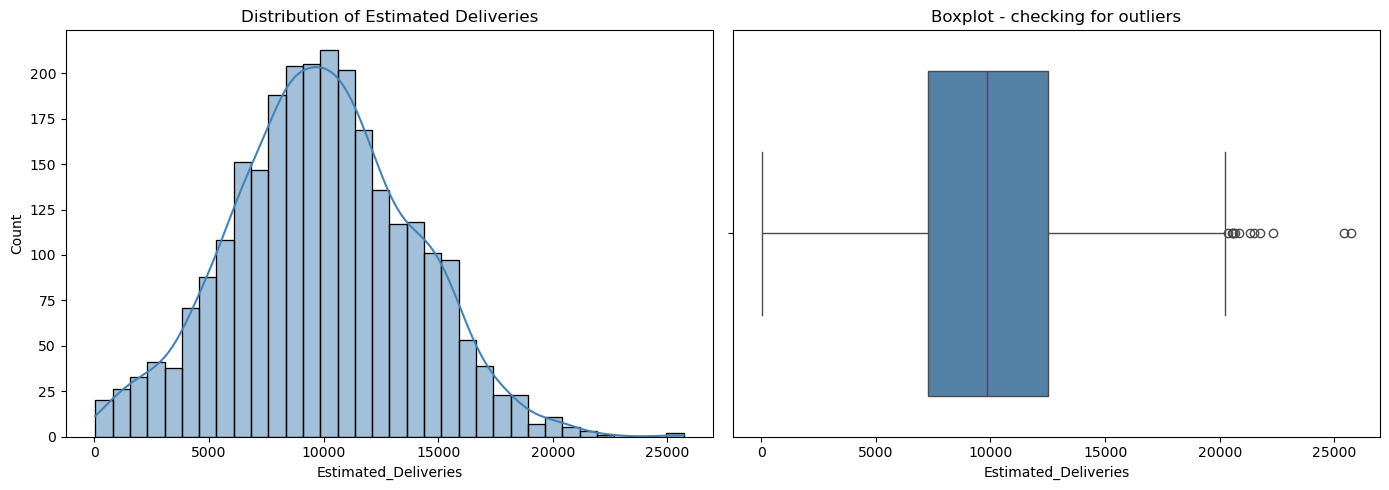

skewness: 0.088


In [16]:
# distribution of target variable - checking if its skewed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Estimated_Deliveries'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Estimated Deliveries')

sns.boxplot(x=df['Estimated_Deliveries'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot - checking for outliers')

plt.tight_layout()
plt.show()

print('skewness:', round(df['Estimated_Deliveries'].skew(), 3))

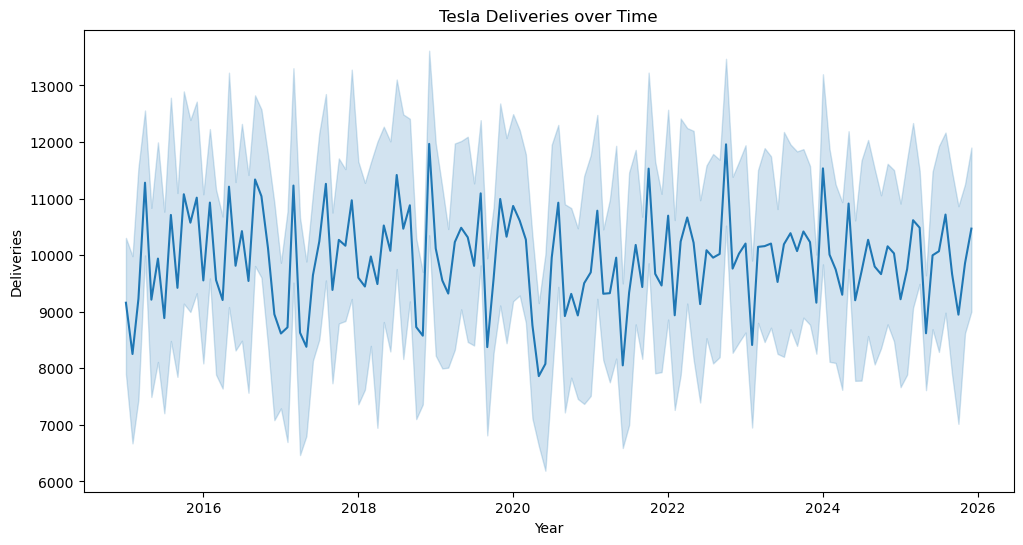

In [17]:
# deliveries over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='Estimated_Deliveries', data=df)
plt.title('Tesla Deliveries over Time')
plt.xlabel('Year')
plt.ylabel('Deliveries')
plt.show()

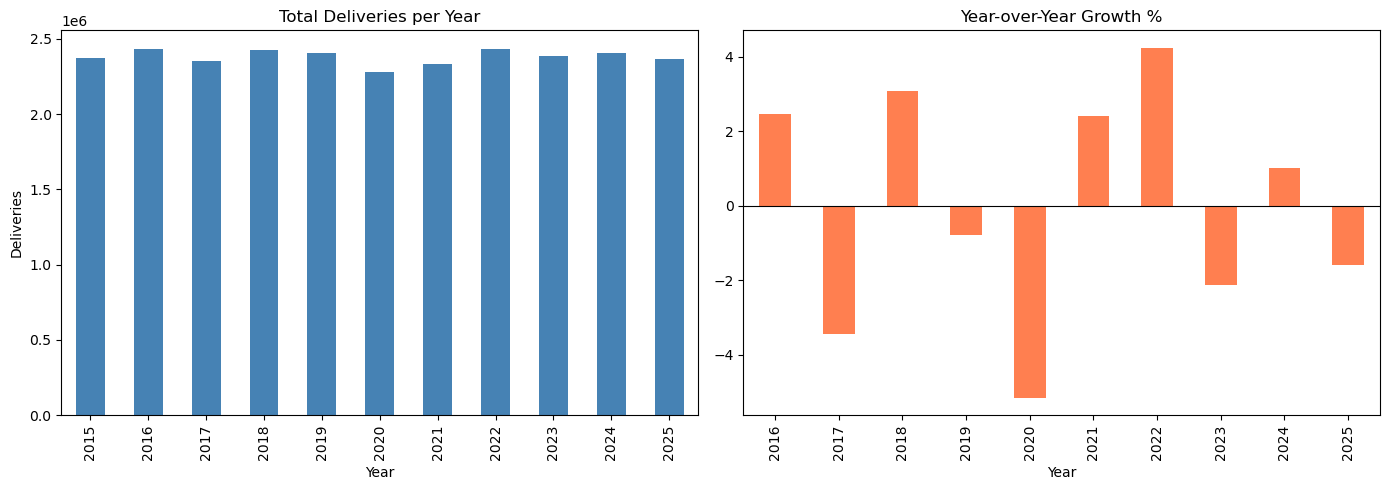

In [18]:
# year over year growth - this shows the growth trend more clearly
yoy = df.groupby('Year')['Estimated_Deliveries'].sum()
yoy_growth = yoy.pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yoy.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Deliveries per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Deliveries')

yoy_growth.dropna().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Year-over-Year Growth %')
axes[1].set_xlabel('Year')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

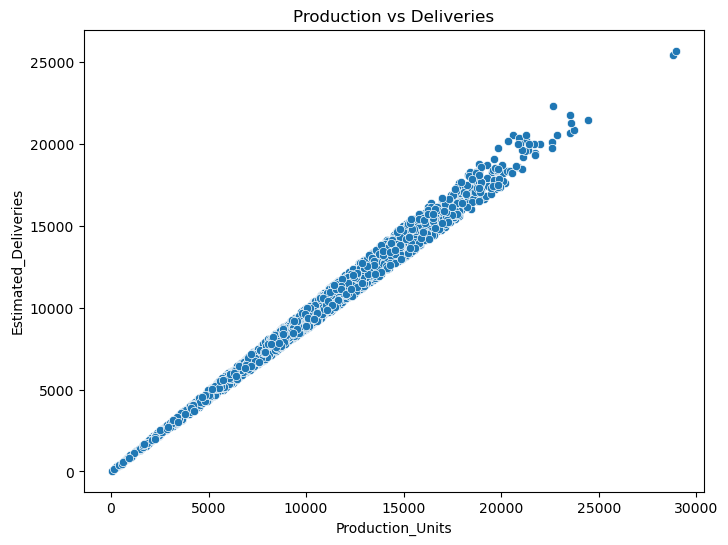

In [19]:
# production vs deliveries scatter
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Production_Units', y='Estimated_Deliveries', data=df)
plt.title('Production vs Deliveries')
plt.show()

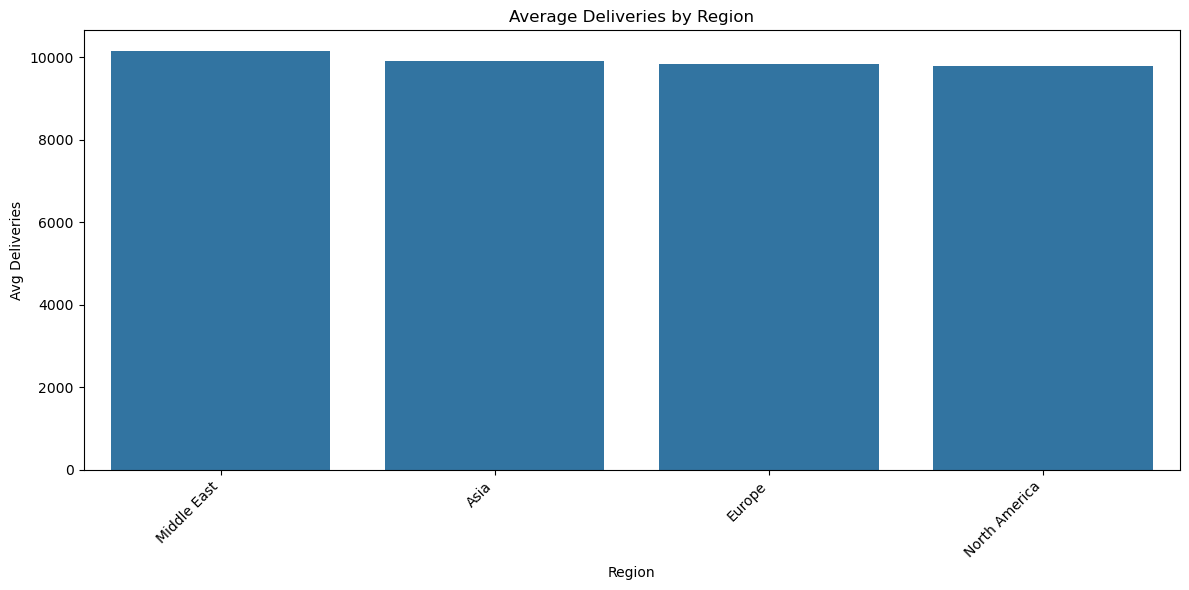

In [20]:
# region-wise deliveries
plt.figure(figsize=(12, 6))
region_avg = df.groupby('Region')['Estimated_Deliveries'].mean().sort_values(ascending=False)
sns.barplot(x=region_avg.index, y=region_avg.values)
plt.xticks(rotation=45, ha='right')
plt.title('Average Deliveries by Region')
plt.ylabel('Avg Deliveries')
plt.tight_layout()
plt.show()

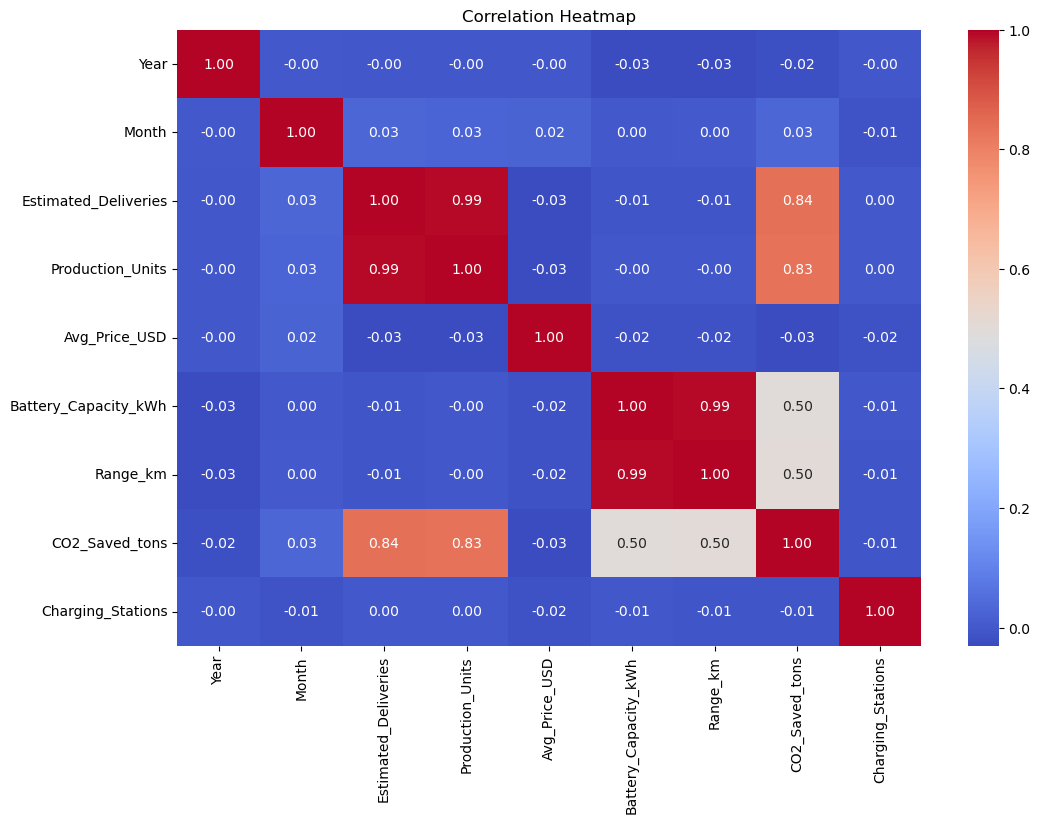

In [21]:
# correlation heatmap - helps identify which features are related to deliveries
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Feature Engineering
creating new useful features from existing columns

In [23]:
# delivery efficiency - how many of the produced units actually got delivered
# replacing 0 with nan first to avoid divide by zero error
df['delivery_ratio'] = df['Estimated_Deliveries'] / df['Production_Units'].replace(0, np.nan)

# price per km - cost efficiency of the vehicle
df['price_per_km'] = df['Avg_Price_USD'] / df['Range_km'].replace(0, np.nan)

# quarter column - helps capture seasonal patterns
df['quarter'] = ((df['Month'] - 1) // 3) + 1

# cyclical encoding for month - regular integer encoding doesnt work well
# because it treats dec->jan as a big jump when its actually just 1 month
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# lag feature - previous months deliveries (strong predictor)
df['lag_1'] = df['Estimated_Deliveries'].shift(1)

# 3 month rolling average - smoothed version of recent trend
df['rolling_mean_3'] = df['Estimated_Deliveries'].shift(1).rolling(window=3).mean()

# dropping nan rows created by lag/rolling features
df.dropna(inplace=True)
print('dataset shape after feature engineering:', df.shape)

dataset shape after feature engineering: (2637, 19)


## Train Test Split
splitting data BEFORE any encoding or scaling to avoid data leakage

In [25]:
# separating features and target
X = df.drop(columns=['Estimated_Deliveries', 'date'])
y = df['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('train size:', X_train.shape)
print('test size:', X_test.shape)

train size: (2109, 17)
test size: (528, 17)


## Building ML Pipelines
using sklearn Pipeline so encoding and scaling only fits on training data - this prevents data leakage

In [27]:
# detecting column types automatically from dtypes
# this is safer than hardcoding column names manually
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print('numerical columns:', numerical_cols)
print('categorical columns:', categorical_cols)

numerical columns: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'delivery_ratio', 'price_per_km', 'quarter', 'month_sin', 'month_cos', 'lag_1', 'rolling_mean_3']
categorical columns: ['Region', 'Model']


In [28]:
# column transformer handles numerical and categorical columns separately
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
], remainder='drop')

# linear regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# random forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print('both models trained successfully')

both models trained successfully


## Model Evaluation
comparing linear regression vs random forest

In [30]:
# function to evaluate any model and return all metrics
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pred = pipeline.predict(X_te)
    cv_score = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='r2').mean()
    return {
        'Model': name,
        'R2 (test)': round(r2_score(y_te, pred), 4),
        'R2 (5-fold CV)': round(cv_score, 4),
        'MAE': round(mean_absolute_error(y_te, pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, pred)), 2)
    }

results = []
results.append(evaluate_model('Linear Regression', lr_pipeline, X_train, y_train, X_test, y_test))
results.append(evaluate_model('Random Forest', rf_pipeline, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model  R2 (test)  R2 (5-fold CV)    MAE   RMSE
Linear Regression     0.9985          0.9984 104.94 147.69
    Random Forest     0.9993          0.9979  62.31  98.02


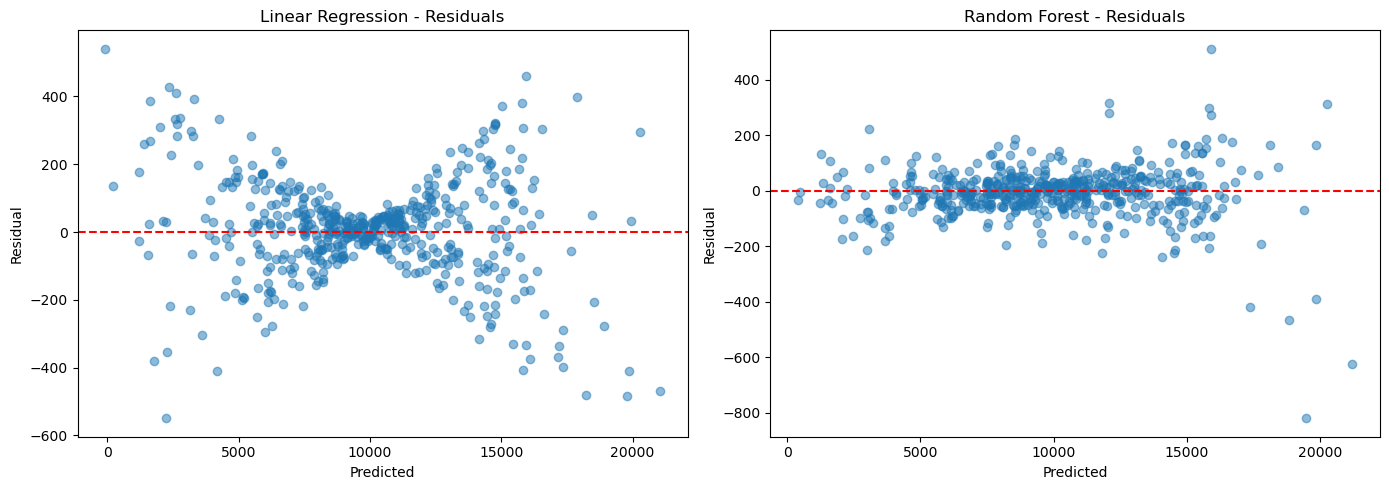

In [31]:
# residual plots - checking if model errors are randomly distributed (they should be)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, pipeline in zip(axes,
                               ['Linear Regression', 'Random Forest'],
                               [lr_pipeline, rf_pipeline]):
    pred = pipeline.predict(X_test)
    residuals = y_test - pred
    ax.scatter(pred, residuals, alpha=0.5)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f'{name} - Residuals')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')

plt.tight_layout()
plt.show()

## Hyperparameter Tuning
trying to improve the random forest model by tuning its parameters

In [33]:
# note: param names need 'model__' prefix because they are inside a pipeline
params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    rf_pipeline,
    params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Production_Units',
                                                                          'Avg_Price_USD',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'CO2_Saved_tons',
                                                                          'Charging_Stations',
                                                                          'delivery_ratio',
                                                                          'price_per_km',
                                                                          'quarter',
                                                                          'month_sin',
                                                                          'month_cos',
                                                                          'lag_1',
                                                                          'rolling_mean_3']),
                                                                        ('cat',
                                                                         OneHotEncode..._unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['Region',
                                                                          'Model'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [34]:
print('best parameters found:')
print(grid.best_params_)

best parameters found:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [35]:
best_model = grid.best_estimator_

# adding tuned rf to comparison table
results.append(evaluate_model('RF Tuned', best_model, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results)
print('=== Final Model Comparison ===')
print(results_df.to_string(index=False))

=== Final Model Comparison ===
            Model  R2 (test)  R2 (5-fold CV)    MAE   RMSE
Linear Regression     0.9985          0.9984 104.94 147.69
    Random Forest     0.9993          0.9979  62.31  98.02
         RF Tuned     0.9759          0.9641 374.59 593.23


## Feature Importance
shows which features are most important for predicting deliveries

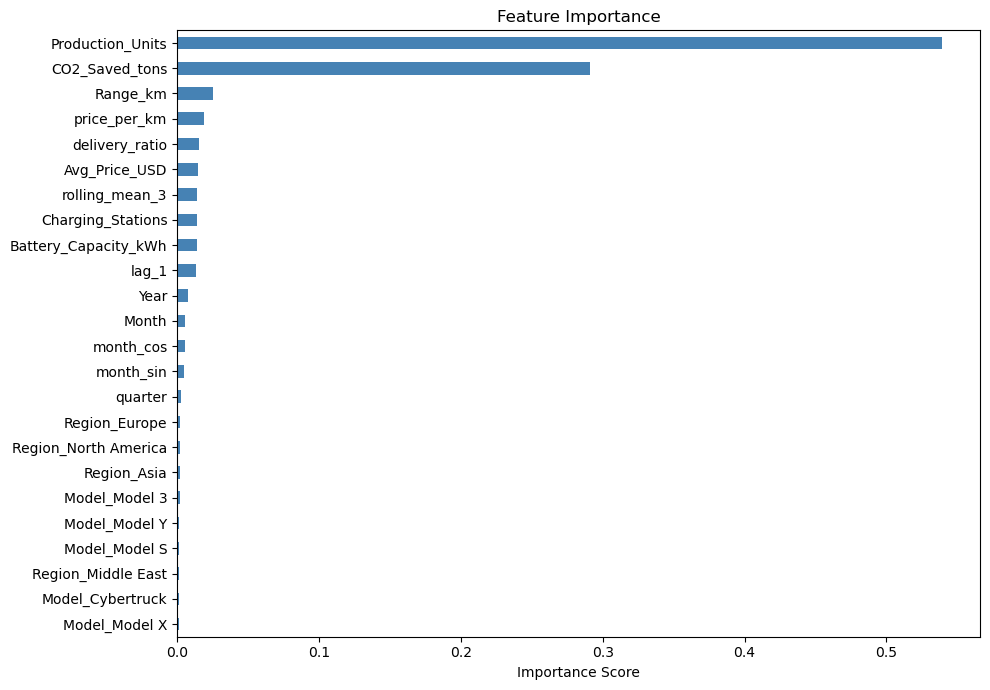

In [37]:
# getting feature names after one-hot encoding
ohe_feature_names = (best_model
                     .named_steps['preprocessor']
                     .named_transformers_['cat']
                     .get_feature_names_out(categorical_cols).tolist())

all_feature_names = numerical_cols + ohe_feature_names

importance = pd.Series(
    best_model.named_steps['model'].feature_importances_,
    index=all_feature_names
).sort_values()

importance.plot(kind='barh', figsize=(10, 7), color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Time Series Forecasting
using SARIMA to predict future deliveries - ARIMA with seasonal component since tesla deliveries peak at quarter end

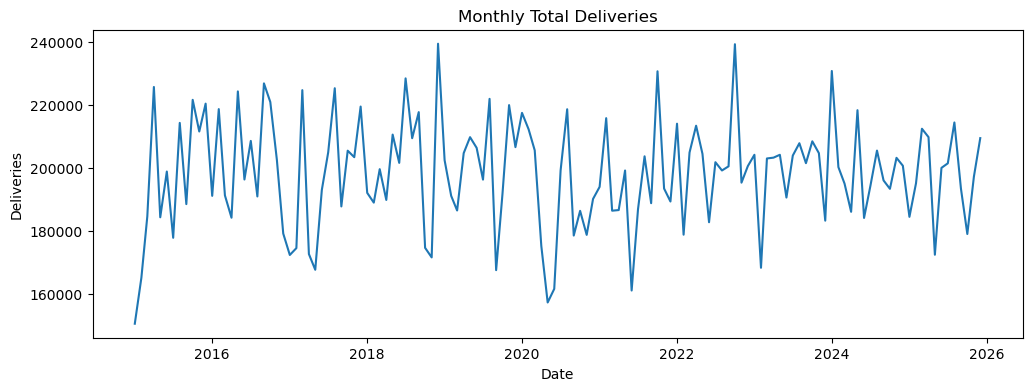

In [39]:
# aggregate to monthly total deliveries for time series
ts = df.groupby('date')['Estimated_Deliveries'].sum().sort_index()

plt.figure(figsize=(12, 4))
plt.plot(ts)
plt.title('Monthly Total Deliveries')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.show()

In [40]:
# stationarity check using ADF test before modeling
# if p-value < 0.05 the series is stationary (good for ARIMA)
adf = adfuller(ts.dropna())
print(f'ADF Statistic : {adf[0]:.4f}')
print(f'p-value       : {adf[1]:.4f}')
print('Result:', 'stationary' if adf[1] < 0.05 else 'non-stationary - differencing needed')

ADF Statistic : -8.9602
p-value       : 0.0000
Result: stationary


In [41]:
# holding out last 6 months to test forecast accuracy
HOLDOUT = 6
ts_train = ts.iloc[:-HOLDOUT]
ts_test  = ts.iloc[-HOLDOUT:]

print('train period:', ts_train.index[0].date(), 'to', ts_train.index[-1].date())
print('test period :', ts_test.index[0].date(),  'to', ts_test.index[-1].date())

train period: 2015-01-01 to 2025-06-01
test period : 2025-07-01 to 2025-12-01


In [42]:
# auto_arima finds the best (p,d,q) order automatically using AIC
# m=3 because tesla deliveries have quarterly seasonality
auto_model = pm.auto_arima(
    ts_train,
    seasonal=True,
    m=3,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True
)
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  126
Model:                        SARIMAX   Log Likelihood               -1409.748
Date:                Sat, 30 May 2026   AIC                           2823.496
Time:                        22:10:59   BIC                           2829.169
Sample:                    01-01-2015   HQIC                          2825.801
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1.982e+05   1567.428    126.419      0.000    1.95e+05    2.01e+05
sigma2       3.06e+08   4.02e+07      7.610      0.000    2.27e+08    3.85e+08
Ljung-Box (L1) (Q):                   0.22   Jarque-

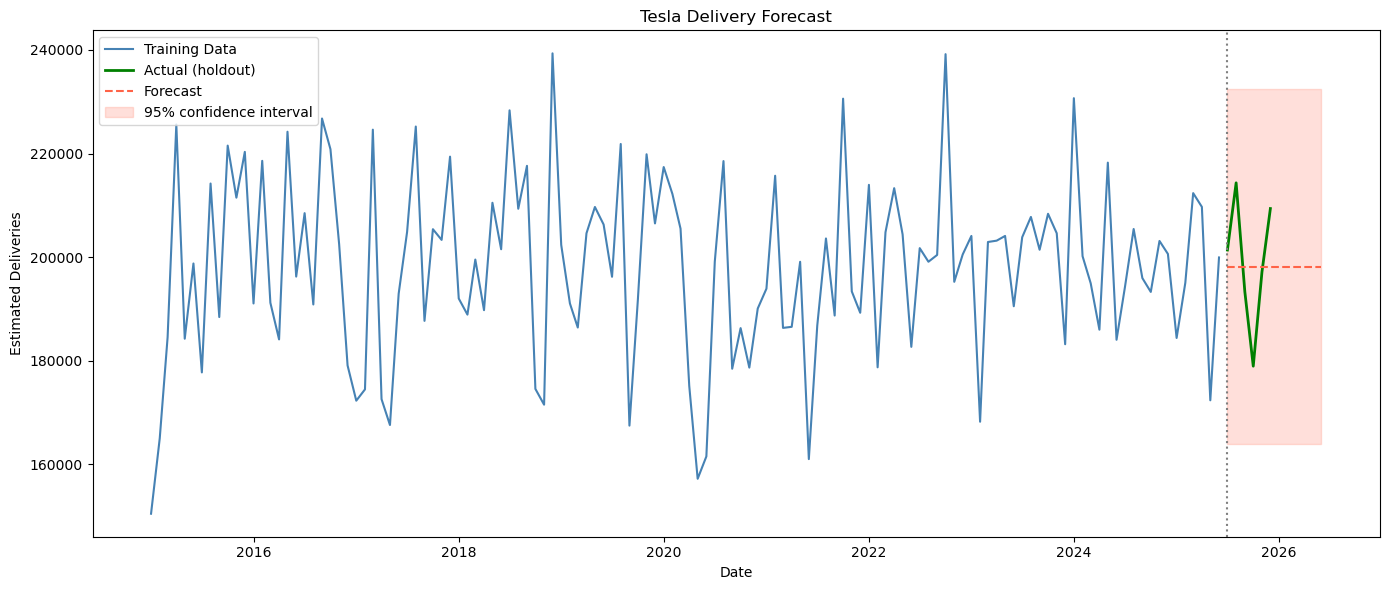

In [43]:
# forecasting 6 holdout months + 6 future months
n_forecast = HOLDOUT + 6
forecast_vals, conf_int = auto_model.predict(n_periods=n_forecast, return_conf_int=True)
forecast_idx = pd.date_range(start=ts_test.index[0], periods=n_forecast, freq='MS')

# plot everything together
plt.figure(figsize=(14, 6))
plt.plot(ts_train.index, ts_train, label='Training Data', color='steelblue')
plt.plot(ts_test.index, ts_test, label='Actual (holdout)', color='green', linewidth=2)
plt.plot(forecast_idx, forecast_vals, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(forecast_idx, conf_int[:, 0], conf_int[:, 1],
                 alpha=0.2, color='tomato', label='95% confidence interval')
plt.axvline(x=ts_test.index[0], color='gray', linestyle=':', linewidth=1.5)
plt.title('Tesla Delivery Forecast')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# checking how accurate the forecast was on the holdout period
holdout_pred = forecast_vals[:HOLDOUT]
print(f'ARIMA MAE  : {mean_absolute_error(ts_test, holdout_pred):,.0f}')
print(f'ARIMA RMSE : {np.sqrt(mean_squared_error(ts_test, holdout_pred)):,.0f}')

ARIMA MAE  : 9,282
ARIMA RMSE : 11,487


## Saving the model

In [46]:
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/tesla_model.pkl')
print('model saved to models/tesla_model.pkl')

model saved to models/tesla_model.pkl
